# Supplements Sale
Overview

This dataset contains weekly sales data for a variety of health and wellness supplements from January 2020 to April 2025. The data includes products in categories like Protein, Vitamins, Omega, and Amino Acids, among others, and covers multiple e-commerce platforms such as Amazon, Walmart, and iHerb. The dataset also tracks sales in several locations including the USA, UK, and Canada.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings 
import plotly.express as px

In [13]:
warnings.filterwarnings("ignore")

In [14]:
data = pd.read_csv('Supplement_Sales_Weekly_Expanded.csv')
data

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb
...,...,...,...,...,...,...,...,...,...,...
4379,2025-03-31,Melatonin,Sleep Aid,160,47.79,7646.40,0.21,1,USA,iHerb
4380,2025-03-31,Biotin,Vitamin,154,38.12,5870.48,0.22,1,UK,Walmart
4381,2025-03-31,Green Tea Extract,Fat Burner,139,20.40,2835.60,0.12,3,USA,iHerb
4382,2025-03-31,Iron Supplement,Mineral,154,18.31,2819.74,0.23,2,Canada,Amazon


# Inspect the dataset

In [15]:
data.head()

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb


In [16]:
data.shape

(4384, 10)

In [17]:
data.columns

Index(['Date', 'Product Name', 'Category', 'Units Sold', 'Price', 'Revenue',
       'Discount', 'Units Returned', 'Location', 'Platform'],
      dtype='object')

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            4384 non-null   object 
 1   Product Name    4384 non-null   object 
 2   Category        4384 non-null   object 
 3   Units Sold      4384 non-null   int64  
 4   Price           4384 non-null   float64
 5   Revenue         4384 non-null   float64
 6   Discount        4384 non-null   float64
 7   Units Returned  4384 non-null   int64  
 8   Location        4384 non-null   object 
 9   Platform        4384 non-null   object 
dtypes: float64(3), int64(2), object(5)
memory usage: 342.6+ KB


In [19]:
data.describe(include="object")

,Date,Product Name,Category,Location,Platform
count,4384,4384,4384,4384,4384
unique,274,16,10,3,3
top,2020-01-06,Whey Protein,Vitamin,Canada,iHerb
freq,16,274,822,1507,1499


In [20]:
data.nunique()

Date               274
Product Name        16
Category            10
Units Sold          81
Price             2919
Revenue           4326
Discount            26
Units Returned       9
Location             3
Platform             3
dtype: int64

# Check for missing values

In [21]:
data.isnull().sum()

Date              0
Product Name      0
Category          0
Units Sold        0
Price             0
Revenue           0
Discount          0
Units Returned    0
Location          0
Platform          0
dtype: int64

# Check for duplicates

In [22]:
data.duplicated().sum()

np.int64(0)

# Data types

In [23]:
data.dtypes

Date               object
Product Name       object
Category           object
Units Sold          int64
Price             float64
Revenue           float64
Discount          float64
Units Returned      int64
Location           object
Platform           object
dtype: object

In [24]:
data["Date"] = pd.to_datetime(data["Date"])
data

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb
...,...,...,...,...,...,...,...,...,...,...
4379,2025-03-31,Melatonin,Sleep Aid,160,47.79,7646.40,0.21,1,USA,iHerb
4380,2025-03-31,Biotin,Vitamin,154,38.12,5870.48,0.22,1,UK,Walmart
4381,2025-03-31,Green Tea Extract,Fat Burner,139,20.40,2835.60,0.12,3,USA,iHerb
4382,2025-03-31,Iron Supplement,Mineral,154,18.31,2819.74,0.23,2,Canada,Amazon


# Clean column names

In [25]:
data.columns = data.columns.str.strip()

In [26]:
data.columns

Index(['Date', 'Product Name', 'Category', 'Units Sold', 'Price', 'Revenue',
       'Discount', 'Units Returned', 'Location', 'Platform'],
      dtype='object')

In [27]:
daily_sales = data.groupby("Date").agg({
    "Revenue" : "sum", 
    "Units Sold" : "sum", 
    "Units Returned" : "sum"
}).reset_index()

In [28]:
daily_sales

,Date,Revenue,Units Sold,Units Returned
0,2020-01-06,71848.56,2406,19
1,2020-01-13,72416.18,2374,27
2,2020-01-20,76152.42,2370,26
3,2020-01-27,70306.73,2397,29
4,2020-02-03,98011.64,2384,34
...,...,...,...,...
269,2025-03-03,66065.44,2431,36
270,2025-03-10,92509.57,2411,30
271,2025-03-17,65590.53,2381,22
272,2025-03-24,69778.44,2416,27


# Trends over time

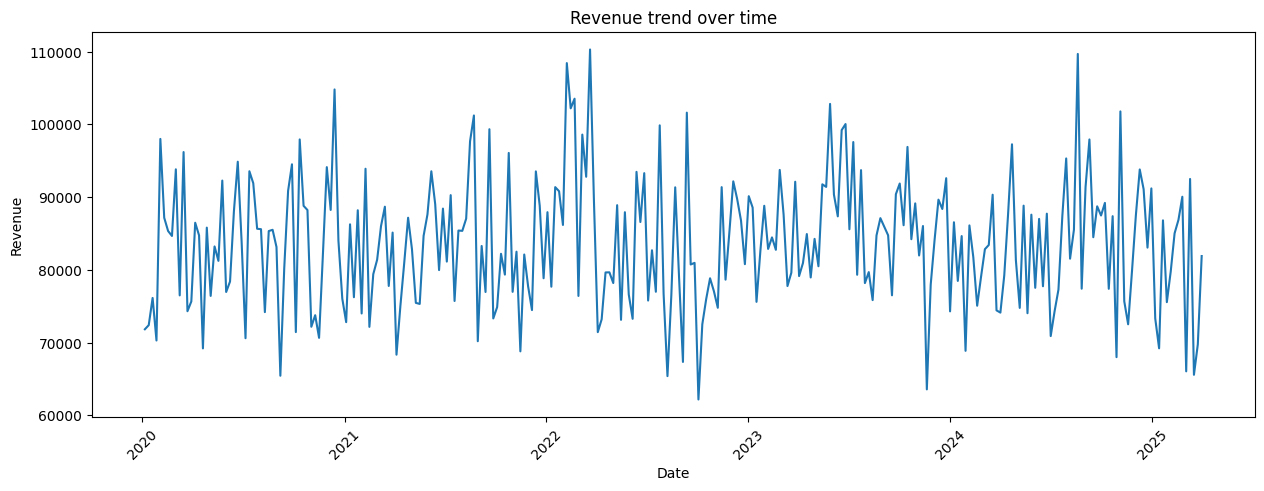

In [29]:
plt.figure(figsize=(15,5))
sns.lineplot(data= daily_sales, x='Date', y='Revenue')
plt.title(f"Revenue trend over time")
plt.xticks(rotation=45)
plt.show()

# Compare categories

In [30]:
category_revenue = data.groupby("Category")["Revenue"].sum().sort_values(ascending=False)
category_revenue

Category
Vitamin        4300224.68
Mineral        4276107.99
Performance    2909702.18
Protein        2855492.09
Amino Acid     1464819.63
Omega          1451065.87
Fat Burner     1440900.05
Hydration      1411951.38
Herbal         1405700.79
Sleep Aid      1397315.79
Name: Revenue, dtype: float64

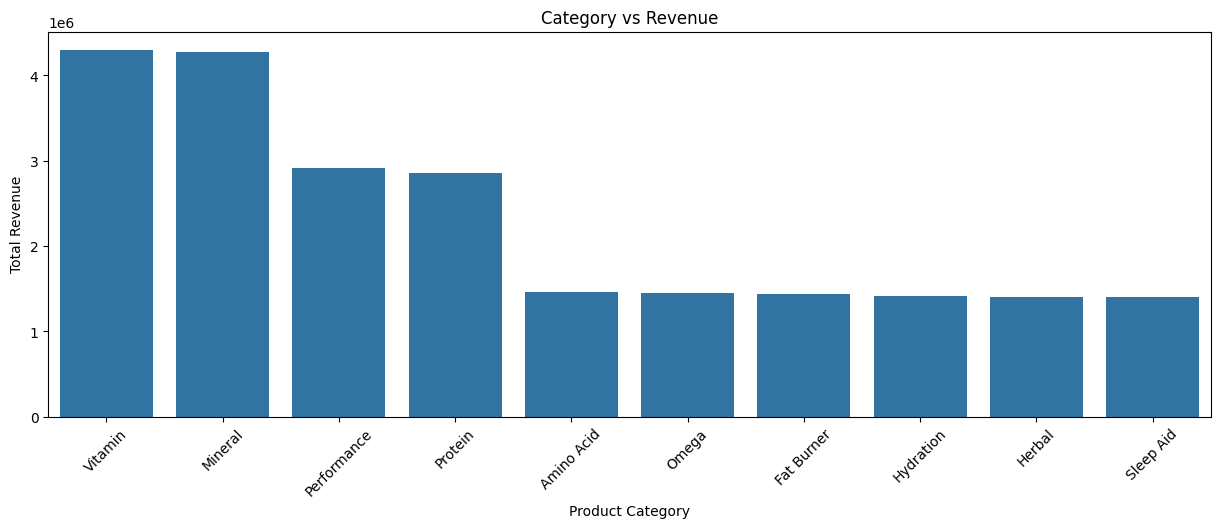

In [31]:
plt.figure(figsize=(15,5))
sns.barplot(x = category_revenue.index, y = category_revenue.values)
plt.title(f"Category vs Revenue")
plt.ylabel("Total Revenue")
plt.xlabel("Product Category")
plt.xticks(rotation = 45)
plt.show()

In [32]:
loc_platform = data.groupby(["Location", "Platform"])["Revenue"].sum().unstack().fillna(0)
loc_platform

Platform,Amazon,Walmart,iHerb
Location,,,
Canada,2613844.28,2518639.07,2716096.38
UK,2442671.23,2637066.25,2624222.86
USA,2612936.27,2232862.30,2514941.81


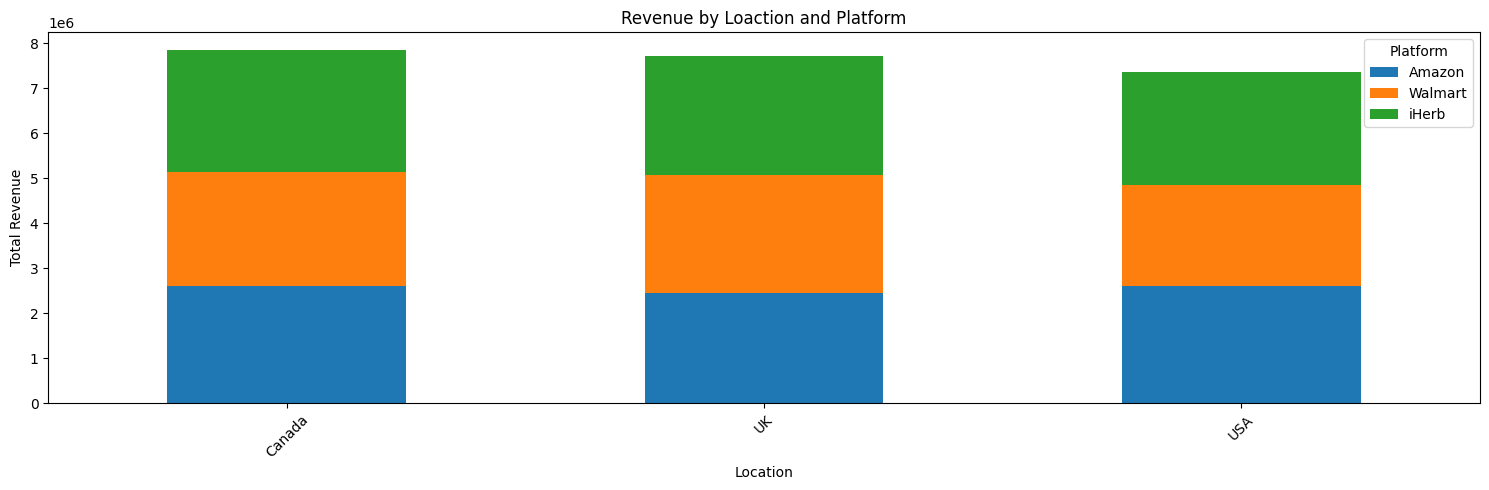

In [33]:
loc_platform.plot(kind='bar', stacked=True, figsize=(15,5))
plt.title(f"Revenue by Loaction and Platform")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
top_products = data.groupby("Product Name")["Revenue"].sum().sort_values(ascending=False).head(10)
top_products

Product Name
Biotin               1486798.62
Zinc                 1482546.95
Pre-Workout          1477183.78
BCAA                 1464819.63
Fish Oil             1451065.87
Green Tea Extract    1440900.05
Collagen Peptides    1433297.24
Creatine             1432518.40
Iron Supplement      1431582.41
Whey Protein         1422194.85
Name: Revenue, dtype: float64

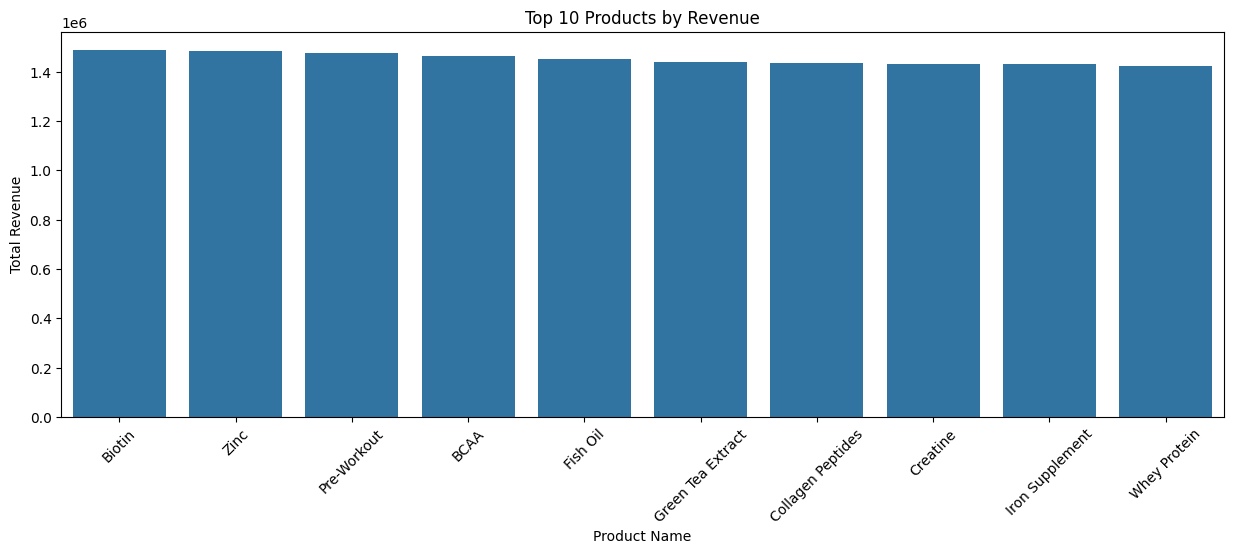

In [35]:
plt.figure(figsize=(15,5))
sns.barplot(x=top_products.index, y=top_products.values)
plt.title(f"Top 10 Products by Revenue")
plt.ylabel("Total Revenue")
plt.xlabel("Product Name")
plt.xticks(rotation = 45)
plt.show()

In [36]:
data["Return Rate"] = data["Units Returned"] / data["Units Sold"]
data

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform,Return Rate
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart,0.013986
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon,0.000000
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon,0.000000
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart,0.000000
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb,0.019108
...,...,...,...,...,...,...,...,...,...,...,...
4379,2025-03-31,Melatonin,Sleep Aid,160,47.79,7646.40,0.21,1,USA,iHerb,0.006250
4380,2025-03-31,Biotin,Vitamin,154,38.12,5870.48,0.22,1,UK,Walmart,0.006494
4381,2025-03-31,Green Tea Extract,Fat Burner,139,20.40,2835.60,0.12,3,USA,iHerb,0.021583
4382,2025-03-31,Iron Supplement,Mineral,154,18.31,2819.74,0.23,2,Canada,Amazon,0.012987


In [37]:
category_return = data.groupby(["Category"])["Return Rate"].mean().sort_values(ascending=False)
category_return

Category
Hydration      0.010746
Vitamin        0.010475
Amino Acid     0.010355
Fat Burner     0.010229
Performance    0.010207
Protein        0.010203
Mineral        0.010079
Omega          0.009870
Sleep Aid      0.009860
Herbal         0.009433
Name: Return Rate, dtype: float64

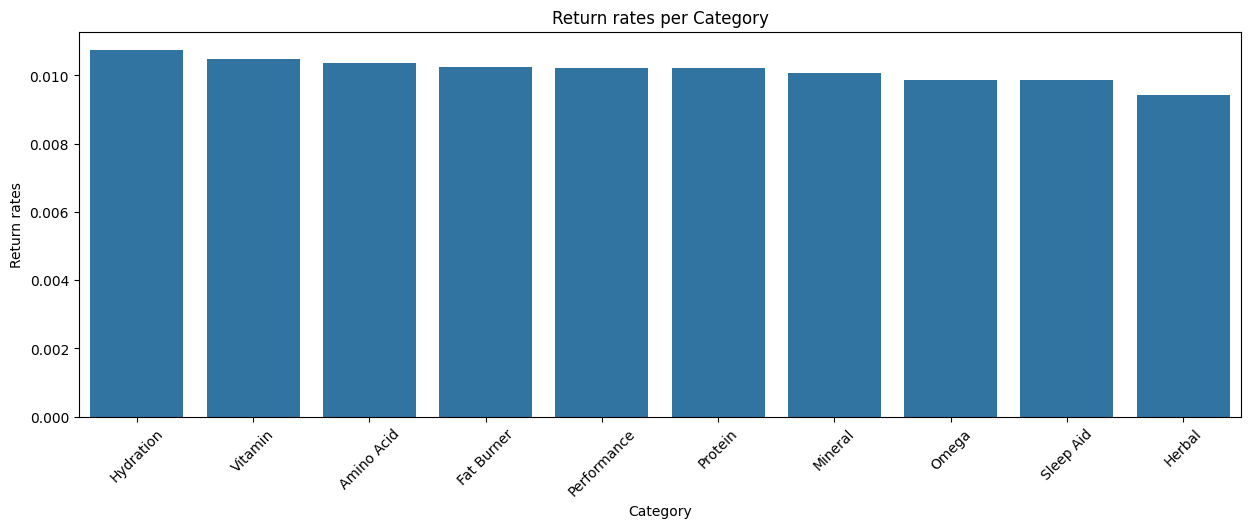

In [38]:
plt.figure(figsize=(15,5))
sns.barplot(x=category_return.index, y=category_return.values)
plt.title(f"Return rates per Category")
plt.ylabel("Return rates")
plt.xticks(rotation=45)
plt.show()

# Check relationships

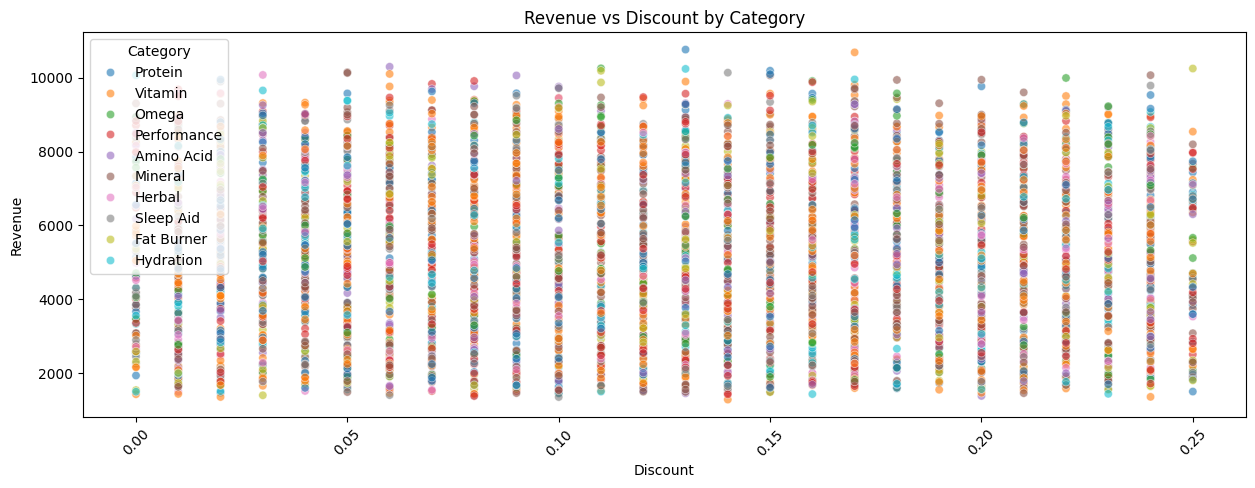

In [39]:
plt.figure(figsize=(15,5))
sns.scatterplot(data=data, x="Discount", y="Revenue", hue="Category", alpha = 0.6)
plt.title(f"Revenue vs Discount by Category")
plt.xticks(rotation=45)
plt.show()

# Correlation analysis

In [40]:
corr = data[["Units Sold", "Price", "Revenue", "Discount", "Units Returned"]].corr()
corr

,Units Sold,Price,Revenue,Discount,Units Returned
Units Sold,1.000000,0.013749,0.210462,-0.010435,0.116523
Price,0.013749,1.000000,0.977198,-0.008668,-0.010410
Revenue,0.210462,0.977198,1.000000,-0.012531,0.012432
Discount,-0.010435,-0.008668,-0.012531,1.000000,0.004276
Units Returned,0.116523,-0.010410,0.012432,0.004276,1.000000


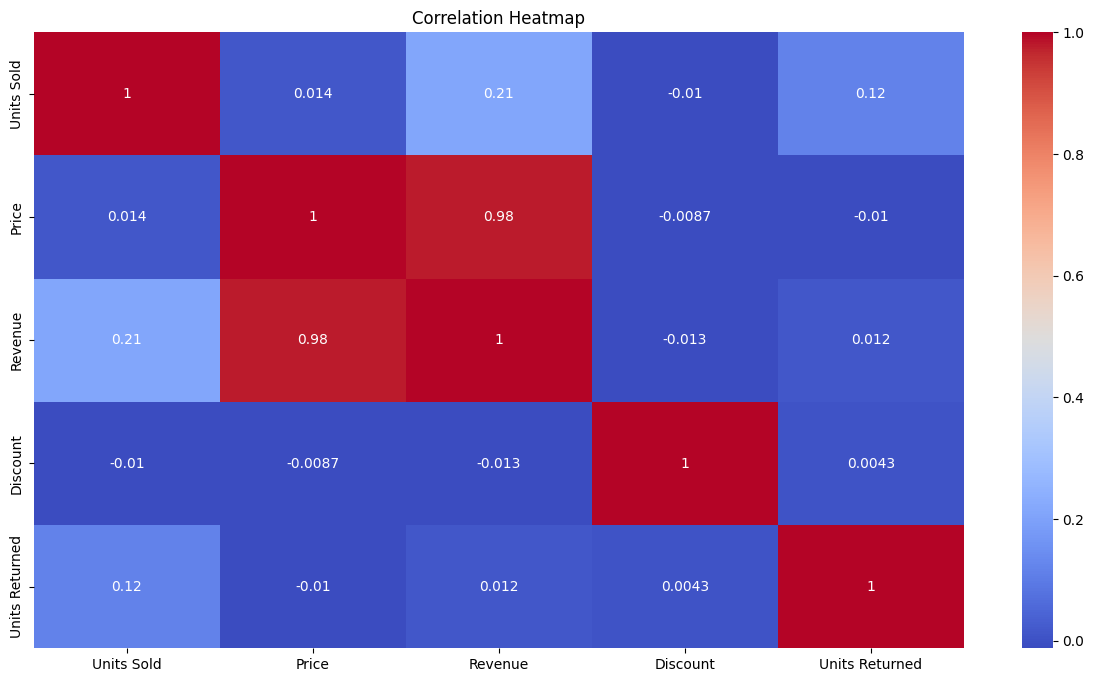

In [41]:
plt.figure(figsize=(15,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title(f"Correlation Heatmap")
plt.show()

In [42]:
fig = px.line(data, x="Date", y="Revenue", color="Category", title="Revenue over time by Category")
fig.show()

In [43]:
data["Monthly"] = data["Date"].dt.to_period("M")
monthly = data.groupby("Monthly").agg({
    "Revenue": "sum", 
    "Units Sold" : "sum",
    "Discount" : "mean",
    "Units Returned" : "sum"
}).reset_index()
monthly 

,Monthly,Revenue,Units Sold,Discount,Units Returned
0,2020-01,290723.89,9547,0.120313,101
1,2020-02,355213.26,9493,0.128125,91
2,2020-03,416547.17,12145,0.111375,123
3,2020-04,326287.92,9605,0.138281,91
4,2020-05,333210.99,9557,0.119375,90
...,...,...,...,...,...
58,2024-11,329894.33,9838,0.117813,106
59,2024-12,446728.99,12042,0.127125,99
60,2025-01,304965.15,9617,0.125156,92
61,2025-02,341768.25,9542,0.128125,103


In [44]:
monthly["Monthly"] = monthly["Monthly"].astype(str)

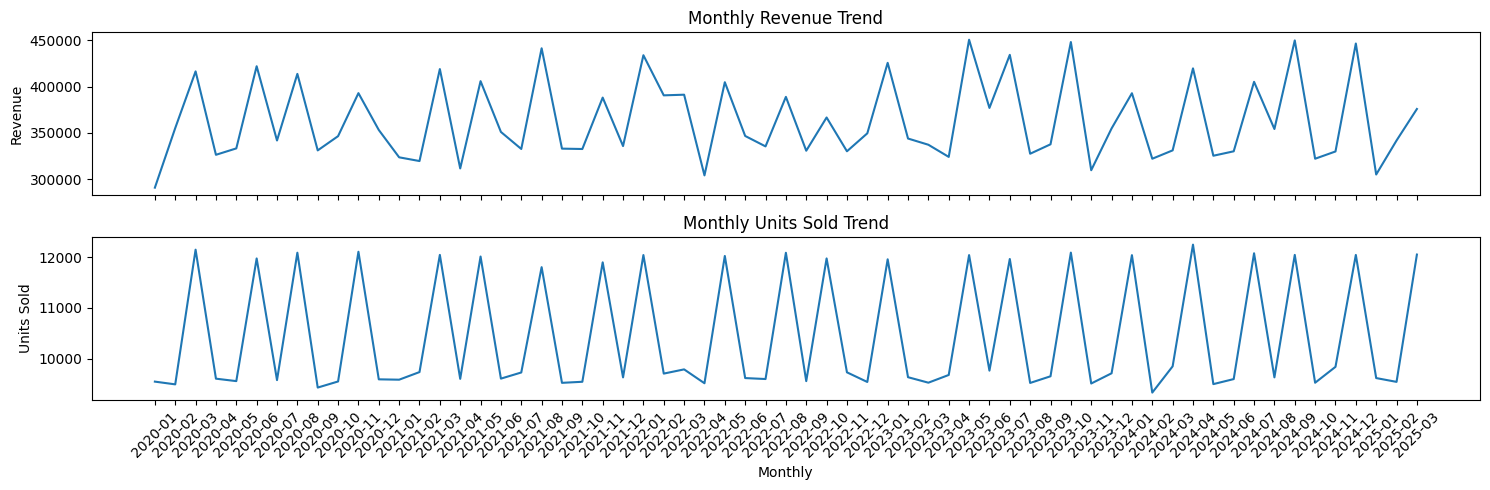

In [47]:
fig, axes = plt.subplots(2,1, figsize=(15,5), sharex=True)
sns.lineplot(data=monthly, x="Monthly", y="Revenue", ax = axes[0])
axes[0].set_title("Monthly Revenue Trend")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(data=monthly, x="Monthly", y="Units Sold", ax=axes[1])
axes[1].set_title("Monthly Units Sold Trend")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [51]:
data["Net Revenue"] = data["Revenue"] - (data["Units Returned"] * data["Price"] * (1 - data["Discount"]))
data.head()

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform,Return Rate,Monthly,Net Revenue
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart,0.013986,2020-01,4511.0988
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon,0.000000,2020-01,5908.8900
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon,0.000000,2020-01,2078.5100
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart,0.000000,2020-01,2249.8000
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb,0.019108,2020-01,5488.9825


In [52]:
category_profit = data.groupby("Category")["Net Revenue"].sum().sort_values(ascending=False)
category_profit

Category
Vitamin        4.260951e+06
Mineral        4.238539e+06
Performance    2.883582e+06
Protein        2.830554e+06
Amino Acid     1.451278e+06
Omega          1.438774e+06
Fat Burner     1.427997e+06
Hydration      1.398561e+06
Herbal         1.394053e+06
Sleep Aid      1.385159e+06
Name: Net Revenue, dtype: float64

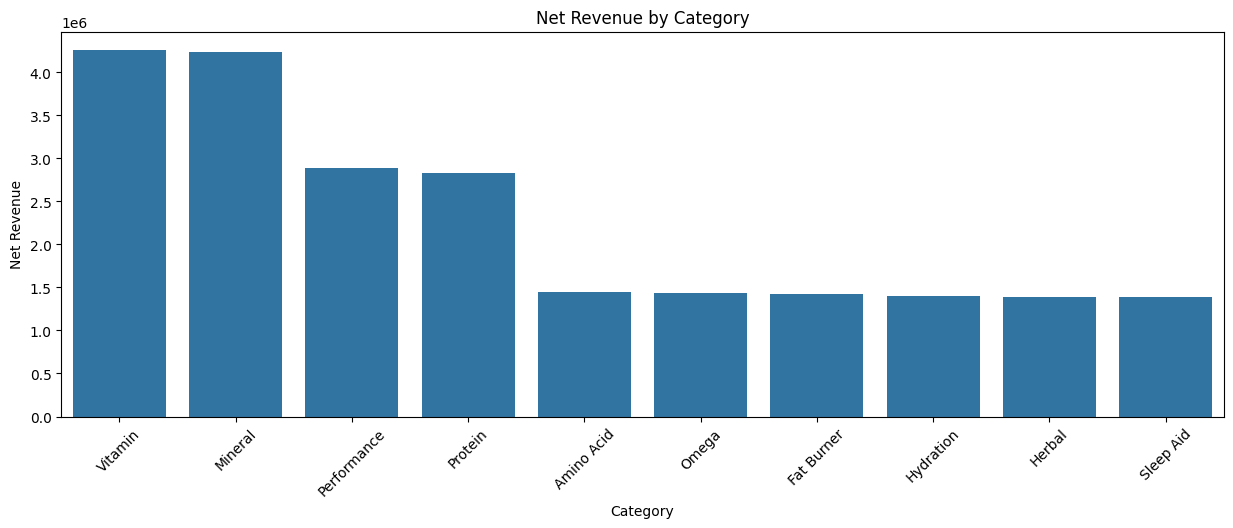

In [53]:
plt.figure(figsize=(15,5))
sns.barplot(x=category_profit.index, y=category_profit.values)
plt.title(f"Net Revenue by Category")
plt.ylabel("Net Revenue")
plt.xticks(rotation=45)
plt.show()

In [54]:
data.to_csv('Supplement_Sales_Weekly_Cleaned.csv')